# Task 2 – Conditional GAN (CGAN)

## Objective
Build a Conditional Generative Adversarial Network (CGAN) that generates simple grayscale images based on class labels. The model should learn to generate a **circle** when given the label **"circle"** and a **square** when given the label **"square"**.

## Steps Performed
1. Imported the required Python libraries.
2. Generated a custom dataset containing circles and squares.
3. Loaded and preprocessed the dataset using `ImageFolder` and `DataLoader`.
4. Built the Conditional Generator and Discriminator models.
5. Defined the loss function and Adam optimizers.
6. Trained the CGAN for 100 epochs.
7. Generated images using random noise and class labels.
8. Visualized the generated circle and square to evaluate the model's performance.

## Outcome
The trained CGAN successfully generated different shapes according to the provided labels, demonstrating conditional image generation.

In [1]:
!pip install -q torch torchvision matplotlib tqdm

In [2]:
import os

folders = [
    "dataset",
    "dataset/circle",
    "dataset/square",
    "models",
    "outputs",
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [12]:
from PIL import Image, ImageDraw
import random
import os

SIZE = 64
NUM_IMAGES = 3000

def create_circle():
    img = Image.new("L", (SIZE, SIZE), 0)
    draw = ImageDraw.Draw(img)

    r = random.randint(10, 22)
    x = random.randint(r + 2, SIZE - r - 2)
    y = random.randint(r + 2, SIZE - r - 2)

    draw.ellipse((x-r, y-r, x+r, y+r), fill=255)
    return img

def create_square():
    img = Image.new("L", (SIZE, SIZE), 0)
    draw = ImageDraw.Draw(img)

    s = random.randint(18, 36)
    x = random.randint(2, SIZE - s - 2)
    y = random.randint(2, SIZE - s - 2)

    draw.rectangle((x, y, x+s, y+s), fill=255)
    return img

for i in range(NUM_IMAGES):
    create_circle().save(f"dataset/circle/circle_{i}.png")
    create_square().save(f"dataset/square/square_{i}.png")

print("Dataset generated successfully!")

Dataset generated successfully!


In [13]:
!find dataset/square | head -20

dataset/square
dataset/square/square_29.png
dataset/square/square_2805.png
dataset/square/square_149.png
dataset/square/square_1281.png
dataset/square/square_2456.png
dataset/square/square_1816.png
dataset/square/square_2866.png
dataset/square/square_7.png
dataset/square/square_438.png
dataset/square/square_2759.png
dataset/square/square_726.png
dataset/square/square_1457.png
dataset/square/square_957.png
dataset/square/square_899.png
dataset/square/square_1210.png
dataset/square/square_1815.png
dataset/square/square_1695.png
dataset/square/square_2693.png
dataset/square/square_2735.png


In [14]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [15]:
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.ImageFolder(
    root="dataset",
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

print("Classes:", dataset.classes)
print("Images:", len(dataset))

Classes: ['circle', 'square']
Images: 6000


In [17]:
import torch
import torch.nn as nn

latent_dim = 100
num_classes = len(dataset.classes)
img_size = 64

# Generator

class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, 50)

        self.project = nn.Sequential(
            nn.Linear(latent_dim + 50, 512 * 4 * 4),
            nn.BatchNorm1d(512 * 4 * 4),
            nn.ReLU(True)
        )

        self.net = nn.Sequential(
            nn.ConvTranspose2d(512,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64,1,4,2,1),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label = self.label_emb(labels)
        x = torch.cat((noise, label), dim=1)
        x = self.project(x)
        x = x.view(-1,512,4,4)
        return self.net(x)

# Discriminator

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, img_size * img_size)

        self.net = nn.Sequential(
            nn.Conv2d(2,64,4,2,1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256,512,4,2,1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(512*4*4,1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        label = self.label_emb(labels)
        label = label.view(-1,1,img_size,img_size)

        x = torch.cat((img,label), dim=1)
        return self.net(x)


generator = Generator().to(device)
discriminator = Discriminator().to(device)

print(generator)
print(discriminator)

Generator(
  (label_emb): Embedding(2, 50)
  (project): Sequential(
    (0): Linear(in_features=150, out_features=8192, bias=True)
    (1): BatchNorm1d(8192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (net): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): Tanh()
  )
)
Discrimin

In [19]:
import torch
import torch.nn as nn
from tqdm import tqdm

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

epochs = 100

for epoch in range(epochs):

    for real_images, labels in tqdm(loader, leave=False):

        real_images = real_images.to(device)
        labels = labels.to(device)

        batch_size = real_images.size(0)

        real_targets = torch.ones(batch_size, 1, device=device) * 0.9
        fake_targets = torch.zeros(batch_size, 1, device=device)

        # Train Discriminator

        optimizer_D.zero_grad()

        output_real = discriminator(real_images, labels)
        loss_real = criterion(output_real, real_targets)

        noise = torch.randn(batch_size, latent_dim, device=device)
        fake_images = generator(noise, labels)

        output_fake = discriminator(fake_images.detach(), labels)
        loss_fake = criterion(output_fake, fake_targets)

        d_loss = (loss_real + loss_fake) / 2

        d_loss.backward()
        optimizer_D.step()

        # Train Generator

        optimizer_G.zero_grad()

        noise = torch.randn(batch_size, latent_dim, device=device)
        fake_images = generator(noise, labels)

        output = discriminator(fake_images, labels)

        g_loss = criterion(output, real_targets)

        g_loss.backward()
        optimizer_G.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"D Loss: {d_loss.item():.4f} | "
        f"G Loss: {g_loss.item():.4f}"
    )

print("Training Complete!")

Epoch [1/100] | D Loss: 0.2647 | G Loss: 5.0284


Epoch [2/100] | D Loss: 0.1931 | G Loss: 1.7739


Epoch [3/100] | D Loss: 0.2318 | G Loss: 3.4425


Epoch [4/100] | D Loss: 0.1900 | G Loss: 4.6813


Epoch [5/100] | D Loss: 0.1806 | G Loss: 5.5465


...

Epoch [96/100] | D Loss: 0.1658 | G Loss: 6.4083


Epoch [97/100] | D Loss: 0.1744 | G Loss: 6.4737


Epoch [98/100] | D Loss: 0.1702 | G Loss: 5.1928


Epoch [99/100] | D Loss: 0.1647 | G Loss: 2.5215


Epoch [100/100] | D Loss: 0.2091 | G Loss: 2.7493
Training Complete!


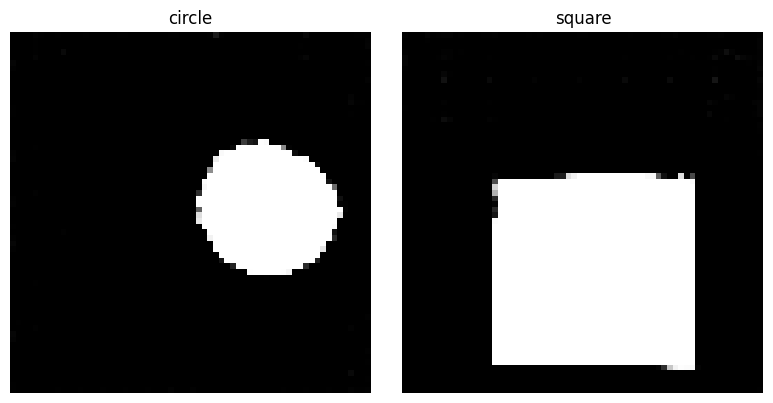

In [20]:
import torch
import matplotlib.pyplot as plt

generator.eval()

num_samples = num_classes

noise = torch.randn(num_samples, latent_dim).to(device)
labels = torch.arange(num_classes).to(device)

with torch.no_grad():
    generated = generator(noise, labels).cpu()

fig, axes = plt.subplots(1, num_classes, figsize=(4 * num_classes, 4))

if num_classes == 1:
    axes = [axes]

for i in range(num_classes):
    img = generated[i].squeeze()
    img = (img + 1) / 2  # Convert from [-1,1] to [0,1]

    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(dataset.classes[i])
    axes[i].axis("off")

plt.tight_layout()
plt.show()